# Playground

In [22]:
import geopandas as gpd
import osmnx
import pandas as pd
import shapely
from osmnx import nearest_nodes
from shapely.geometry.linestring import LineString
from shapely.ops import unary_union, split
import networkx as nx
import osmnx as ox
import momepy
import matplotlib.pyplot as plt
import contextily as cx
from scipy.spatial import KDTree

In [23]:
def plot_maps(*maps):
    fig, ax = plt.subplots()
    for map, color in maps:
        map.plot(ax=ax, color=color)
    cx.add_basemap(ax=ax, crs=maps[0][0].crs, source=cx.providers.CartoDB.Positron)
    plt.show()

## Validate CRS function

In [ ]:
def validate_crs(gdf):
    if gdf.crs.is_geographic:
        gdf = gdf.to_crs(epsg=4326)
        gdf = gdf.to_crs(gdf.estimate_utm_crs())
    if not gdf.crs:
        gdf = gdf.set_crs(epsg=4326)
        gdf = gdf.to_crs(gdf.estimate_utm_crs())
    return gdf.crs

## Centroid function

In [ ]:
def get_centroids(gdf):
    crs = validate_crs(gdf)
    gdf = gdf.to_crs(crs)
    gdf['shape_centroid'] = gdf.geometry.centroid
    return gdf

In [ ]:
gdf_shape = gpd.read_file('test_shapes.gpkg')
get_centroids(gdf_shape)

## Segment function

In [ ]:
def preprocess_route(gdf_polylines):
    crs = validate_crs(gdf_polylines)
    gdf_polylines = gdf_polylines.to_crs(crs)

    segmented_lines = unary_union(gdf_polylines.geometry)
    segmented_lines = shapely.get_parts(segmented_lines)
    segments = []
    for line in segmented_lines:
        coords = list(line.coords)
        for i in range(len(coords) - 1):
            segments.append(shapely.geometry.LineString([coords[i], coords[i + 1]]))

    return gpd.GeoDataFrame(geometry=segments, crs=crs)

In [ ]:
_route = gpd.read_file('test_lines2.gpkg')
preprocess_route(_route).geometry

## Snap targets to route function



In [ ]:
def extend_route_to_centroids(route, objects):
    crs = validate_crs(route)
    route = route.to_crs(crs)
    objects = objects.to_crs(crs)

    _ = route.sindex
    _ = objects.sindex

    gdf_snapped = gpd.sjoin_nearest(get_centroids(objects), route, how='left')[['shape_centroid', 'index_right']].drop_duplicates(subset='shape_centroid')
    gdf_snapped = gdf_snapped.merge(route[['geometry']], left_on='index_right', right_index=True)
    gdf_snapped['start_line'] = gdf_snapped['geometry'].interpolate(gdf_snapped['geometry'].project(gdf_snapped['shape_centroid']))
    new_geometries = [LineString([pt1, pt2]) for pt1, pt2 in zip(gdf_snapped['start_line'], gdf_snapped['shape_centroid'])]
    new_gdf = gpd.GeoDataFrame(geometry=new_geometries, crs=crs)
    return pd.concat([route, new_gdf], ignore_index=True)


In [ ]:
snapped_targets = extend_route_to_centroids(preprocess_route(_route), get_centroids(gdf_shape))
# snapped_targets
plot_maps((snapped_targets, 'blue'), (get_centroids(gdf_shape)['shape_centroid'], 'green'), (preprocess_route(_route), 'purple'))

In [ ]:
# Start Here

## Segment line with snapped points function

In [ ]:
_lines = gpd.read_file('test_lines2.gpkg')
_shape = gpd.read_file('test_shapes.gpkg')

_route = preprocess_route(_lines)
_route = extend_route_to_centroids(_route, _shape)
_route = preprocess_route(_route)

plot_maps((_route, 'green'), (_shape, 'lightgreen'), (preprocess_route(_lines), 'purple'), (_shape.centroid, 'red'))

In [ ]:
_route_graph = momepy.gdf_to_nx(_route, approach='primal', length='length', directed=True)
_node_ids = list(_route_graph.nodes)
_node_coords = [node for node in _node_ids]  # coordinates are keys in momepy primal graph
_spatial_index = KDTree(_node_coords)

## Create isochrones function

In [ ]:
def create_isochrones(graph, starting_point, distance, spatial_index, node_ids):
    _, min_idx = spatial_index.query([starting_point.x, starting_point.y])
    nearest_node = node_ids[min_idx]

    isochrone = nx.ego_graph(graph, nearest_node, radius=distance, distance='length', undirected=True)
    isochrone = ox.graph_to_gdfs(isochrone, nodes=False, edges=True)

    return isochrone

### testing polyline graph

In [ ]:
point = _shape.centroid.iloc[0]
point

In [ ]:
i = create_isochrones(_route_graph, _shape.centroid.iloc[0], 1000, _spatial_index, _node_ids)
plot_maps((i, 'red'))

In [ ]:
i.crs

### testing OSM graph

In [ ]:
route_osm_graph = ox.graph_from_polygon(_shape.to_crs(epsg=4326).iloc[0].geometry, network_type='walk')
route_osm = ox.graph_to_gdfs(route_osm_graph, nodes=False, edges=True)
route_osm = momepy.gdf_to_nx(route_osm.to_crs(validate_crs(route_osm)), approach='primal', length='length', directed=True)

node_osm_ids = list(route_osm.nodes)
node_osm_coords = [node for node in node_osm_ids]  # coordinates are keys in momepy primal graph
spatial_osm_index = KDTree(node_osm_coords)

In [ ]:
j = create_isochrones(route_osm, _shape.centroid.iloc[0], 500, spatial_osm_index, node_osm_ids)
plot_maps((j, 'red'))
# j = j.reset_index()

In [ ]:
type(j)

## Accessibility function

In [ ]:
_target = gpd.read_file('test_target.gpkg')
# gpd.sjoin_nearest(target, j.to_crs(target.crs), how='left')
_route = extend_route_to_centroids(_route, _target)
_route = preprocess_route(_route)

In [ ]:
i = create_isochrones(_route_graph, _shape.centroid.iloc[0], 1000, _spatial_index, _node_ids)

In [ ]:
plot_maps((i, 'red'), (_route, 'purple'),  (_target, 'blue'))

In [ ]:
i_p = i.buffer(10).union_all()
c = gpd.sjoin(gpd.GeoDataFrame(geometry=[i_p], crs=_target.crs), _target, how='inner', predicate='intersects')
c

In [ ]:
def isochrone_target_intersection(isochrone, *targets):
    crs = validate_crs(isochrone)

    isochrone_buffered = isochrone.buffer(10).union_all()

    count = 0
    for target in targets:
        target = target.to_crs(crs)
        _ = target.sindex
        joined = target[target.geometry.centroid.within(isochrone_buffered)]
        print(joined.shape)
        if joined.shape[0] != 0:
            count += 1

    return count

In [ ]:
k = create_isochrones(_route_graph, _shape.centroid.iloc[0], 600, _spatial_index, _node_ids)
plot_maps((k, 'red'), (_target.centroid, 'purple'))

In [ ]:
isochrone_target_intersection(i, _target[_target['type'] == 'a'], _target[_target['type'] == 'b'], _target[_target['type'] == 'c'])

In [ ]:
isochrone_target_intersection(k, _target[_target['type'] == 'a'], _target[_target['type'] == 'b'], _target[_target['type'] == 'c'])

## Accessibility analysis function

In [ ]:
_start = gpd.read_file('test_shapes.gpkg')
_target = gpd.read_file('test_target.gpkg')
_route = gpd.read_file('test_lines2.gpkg')

plot_maps((_start, 'green'), (_target, 'lightgreen'), (_route, 'purple'))

In [ ]:
def accessibility_analysis(start, route, distance, *targets):
    crs = validate_crs(route)
    route = route.to_crs(crs)
    route = preprocess_route(route)
    route = extend_route_to_centroids(route, start)
    route = preprocess_route(route)

    for target in targets:
        target = target.to_crs(crs)
        route = extend_route_to_centroids(route, target)
    route = preprocess_route(route)
    start = get_centroids(start)
    start = start.to_crs(crs)

    route = momepy.gdf_to_nx(route, approach='primal', length='length', directed=True)

    node_ids = list(route.nodes)
    node_coords = [node for node in node_ids]
    spatial_index = KDTree(node_coords)
    start['accessibility'] = start.apply(lambda row: isochrone_target_intersection(create_isochrones(route, row['shape_centroid'], distance, spatial_index, node_ids), *targets), axis=1)
    return start

In [ ]:
_targets = [_target[_target['type'] == 'a'], _target[_target['type'] == 'b'], _target[_target['type'] == 'c']]
_start= accessibility_analysis(_start, _route, 1000, *_targets)

In [ ]:
fig, ax = plt.subplots()
_start.plot(ax=ax, column='accessibility', cmap='YlGn', legend=True, categorical=True)
cx.add_basemap(ax=ax, crs=_start.crs, source=cx.providers.CartoDB.Positron)

In [ ]:
route_osm_graph = ox.graph_from_polygon(shapely.box(*_shape.to_crs(epsg=4326).total_bounds), network_type='walk')
route_osm = ox.graph_to_gdfs(route_osm_graph, nodes=False, edges=True)

In [ ]:
start_osm = accessibility_analysis(_start, route_osm, 1000, *_targets)

In [ ]:
start_osm

## Testing OSM api

In [25]:
route_osm_graph = ox.graph_from_address('Sofia, Bulgaria', dist=1000, network_type='walk')
points = ox.features_from_address('Sofia, Bulgaria', tags={'building': True}, dist=1000)
route_osm = momepy.gdf_to_nx(ox.graph_to_gdfs(route_osm_graph, nodes=False, edges=True).to_crs(validate_crs(points)), approach='primal', length='length', directed=True)

In [26]:
node_ids2 = list(route_osm.nodes)
node_coords2 = [node for node in node_ids2]
spatial_index2 = KDTree(node_coords2)

In [27]:
_start = points[points['building'].isin(['apartments'])]
target1 = points[points['building'].isin(['commercial', 'service', 'church'])]
target2 = points[points['building'].isin(['school', 'university', 'kindergarten'])]
target3 = points[points['building'].isin(['restaurant', 'retail'])]

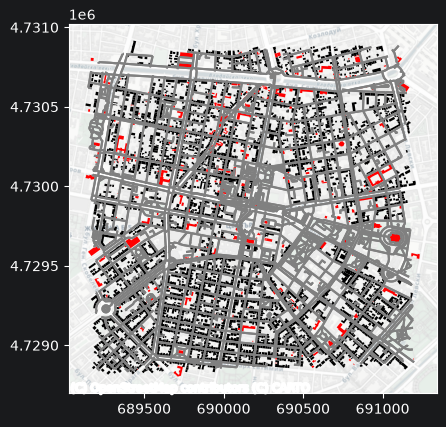

In [28]:
plot_maps(
    (ox.graph_to_gdfs(route_osm_graph, nodes=False, edges=True).to_crs(validate_crs(points)), 'grey'),
    (target1.to_crs(validate_crs(points)), 'red'),
    (target2.to_crs(validate_crs(points)), 'red'),
    (target3.to_crs(validate_crs(points)), 'red'),
    (_start.to_crs(validate_crs(points)), 'black'),
)

In [36]:
_start = accessibility_analysis(_start, ox.graph_to_gdfs(route_osm_graph, nodes=False, edges=True).to_crs(validate_crs(points)), 500, target1)

Preprocessing route finished!


C:\Users\nikit\AppData\Local\Temp\ipykernel_17112\3362366296.py:113: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for j, start_point in enumerate(target.centroid):


Target 1 isochrone 1|80 created!
Target 1 isochrone 2|80 created!
Target 1 isochrone 3|80 created!
Target 1 isochrone 4|80 created!
Target 1 isochrone 5|80 created!
Target 1 isochrone 6|80 created!
Target 1 isochrone 7|80 created!
Target 1 isochrone 8|80 created!
Target 1 isochrone 9|80 created!
Target 1 isochrone 10|80 created!
Target 1 isochrone 11|80 created!
Target 1 isochrone 12|80 created!
Target 1 isochrone 13|80 created!
Target 1 isochrone 14|80 created!
Target 1 isochrone 15|80 created!
Target 1 isochrone 16|80 created!
Target 1 isochrone 17|80 created!
Target 1 isochrone 18|80 created!
Target 1 isochrone 19|80 created!
Target 1 isochrone 20|80 created!
Target 1 isochrone 21|80 created!
Target 1 isochrone 22|80 created!
Target 1 isochrone 23|80 created!
Target 1 isochrone 24|80 created!
Target 1 isochrone 25|80 created!
Target 1 isochrone 26|80 created!
Target 1 isochrone 27|80 created!
Target 1 isochrone 28|80 created!
Target 1 isochrone 29|80 created!
Target 1 isochrone 30|8

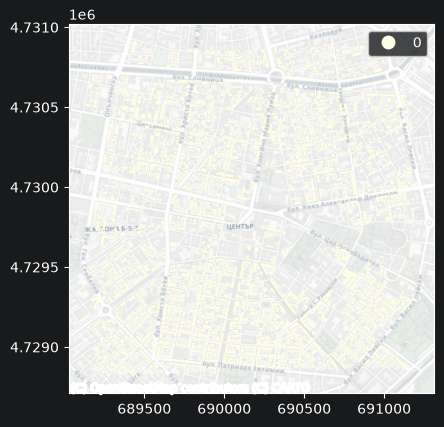

In [37]:
import contextily as cx
fig, ax = plt.subplots()
_start.plot(ax=ax, column='accessibility', cmap='YlGn', legend=True, categorical=True)
# ox.graph_to_gdfs(_route_ret, nodes=False, edges=True).plot(ax=ax, color='black')
cx.add_basemap(ax=ax, crs=_start.crs, source=cx.providers.CartoDB.Positron)

In [ ]:
points.building.unique()

In [ ]:
_start[['geometry', 'accessibility']].to_file('../Generated_Maps/sofia.geojson', driver="GeoJSON")

In [ ]:
sorted(_start.accessibility.unique().tolist())

In [ ]:
start2 = accessibility_analysis(_start, route_osm, 800, _target)

In [ ]:
fig, ax = plt.subplots()
start2.plot(ax=ax, column='accessibility', cmap='YlGn', legend=True, categorical=True)
_target.to_crs(start2.crs).plot(ax=ax, color='red')
# ox.graph_to_gdfs(_route_ret, nodes=False, edges=True).plot(ax=ax, color='black')
cx.add_basemap(ax=ax, crs=start2.crs, source=cx.providers.CartoDB.Positron)

In [ ]:
shape = create_isochrones(route_osm_graph, _start['geometry'].iloc[0].centroid, 800, spatial_index2, node_ids2).buffer(10).union_all()
#
# target1 = target1.to_crs(validate_crs(points))
# target1[target1.centroid.within(shape)]
shape

In [ ]:
from osm_api import osm_api


str = osm_api('Sofia, Bulgaria', 'start', 500)

In [ ]:
str.columns.tolist()

In [ ]:
plot_maps((str, 'b'))

In [ ]:
gm = gpd.read_file('../Generated_Maps/sofia.geojson')
gm.accessibility.unique()

In [35]:
import geopandas as gpd
import pandas as pd
import shapely
from shapely.geometry.linestring import LineString
from shapely.ops import unary_union, split
import networkx as nx
import osmnx as ox
import momepy
from scipy.spatial import KDTree


def validate_crs(gdf):
    if not gdf.crs:
        gdf = gdf.set_crs(epsg=4326)
        gdf = gdf.to_crs(gdf.estimate_utm_crs())
    else:
        if gdf.crs.is_geographic:
            gdf = gdf.to_crs(epsg=4326)
            gdf = gdf.to_crs(gdf.estimate_utm_crs())

    return gdf.crs


def get_centroids(gdf):
    crs = validate_crs(gdf)

    gdf = gdf.to_crs(crs)

    gdf['shape_centroid'] = gdf.geometry.centroid

    return gdf


def preprocess_route(route):
    crs = validate_crs(route)

    route = route.to_crs(crs)

    segmented = unary_union(route.geometry)
    segmented = shapely.get_parts(segmented)

    segments = []
    for line in segmented:
        coords = list(line.coords)
        for i in range(len(coords) - 1):
            segments.append(shapely.geometry.LineString([coords[i], coords[i + 1]]))

    return gpd.GeoDataFrame(geometry=segments, crs=crs)


def extend_route_to_centroids(route, objects):
    crs = validate_crs(route)

    route = route.to_crs(crs)
    objects = objects.to_crs(crs)

    _ = route.sindex
    _ = objects.sindex

    snapped = gpd.sjoin_nearest(get_centroids(objects),
                                    route,
                                    how='left')[['shape_centroid', 'index_right']].drop_duplicates(subset='shape_centroid')
    snapped = snapped.merge(route[['geometry']], left_on='index_right', right_index=True)
    snapped['start_line'] = snapped['geometry'].interpolate(snapped['geometry'].project(snapped['shape_centroid']))

    new_geometries = [LineString([pt1, pt2]) for pt1, pt2 in zip(snapped['start_line'], snapped['shape_centroid'])]
    new_gdf = gpd.GeoDataFrame(geometry=new_geometries, crs=crs)

    return pd.concat([route, new_gdf], ignore_index=True)


def create_isochrones(graph, starting_point, distance, spatial_index, node_ids):
    _, min_idx = spatial_index.query([starting_point.x, starting_point.y])
    nearest_node = node_ids[min_idx]

    isochrone = nx.ego_graph(graph, nearest_node, radius=distance, distance='length', undirected=True)
    isochrone = ox.graph_to_gdfs(isochrone, nodes=False, edges=True)

    return isochrone


def isochrone_target_intersection(isochrone, start):
    isochrone = isochrone.to_crs(start.crs)
    isochrone_buffered = isochrone.buffer(10).union_all()
    start.loc[start.geometry.centroid.within(isochrone_buffered)]['accessibility'] += 1

    return start


def accessibility_analysis(start, route, distance, *targets):
    crs = validate_crs(route)
    route = route.to_crs(crs)
    route = preprocess_route(route)
    route = extend_route_to_centroids(route, start)
    route = preprocess_route(route)

    for target in targets:
        target = target.to_crs(crs)
        route = extend_route_to_centroids(route, target)
    route = preprocess_route(route)
    start = start.to_crs(crs)
    start = get_centroids(start)
    start['accessibility'] = 0

    route = momepy.gdf_to_nx(route, approach='primal', length='length', directed=True)
    print('Preprocessing route finished!')
    node_ids = list(route.nodes)
    node_coords = [node for node in node_ids]
    spatial_index = KDTree(node_coords)

    for i, target in enumerate(targets):
        target_isochrones = []
        for j, start_point in enumerate(target.centroid):
            target_isochrones.append(create_isochrones(route, start_point, distance, spatial_index, node_ids))
            print(f'Target {i + 1} isochrone {j+1}|{len(target)} created!')
        target_isochrone = gpd.GeoDataFrame(pd.concat(target_isochrones, ignore_index=True), crs=crs)
        start = isochrone_target_intersection(target_isochrone, start)
        print(f'Target {i + 1} finished!')
    print('All targets finished!')
    return start